# Prediction code for Utah FORGE data — PyTorch

PyTorch conversion of `USL_DIP_FORGE_EQ36_Pred.ipynb`. It is compatible with the checkpoint produced by `USL_DIP_FORGE_EQ36_Train_PyTorch.py`.

In [1]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

from utils import yc_patch, yc_patch_inv, cseis
from model_torch import DIPAutoencoder1D

# Define paths for figures and models
fig_path = "./Figs/FORGE/"
model_path = "./model/"

# Create directories if they do not exist
os.makedirs(fig_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

# Select GPU when available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


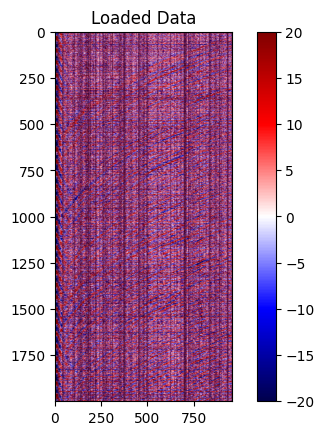

Original data shape: (960, 2000)
Patched data shape: (51967, 576)


In [2]:
# Paths and parameters
data_path = './data/'
eq_num = 36
data_name = f'eq-{eq_num}'

# Patch parameters
w1, w2 = 24, 24
z1, z2 = 6, 6
batch_size = 1024
drop_rate = 0.2
epochs = 50

# Load and visualize data
data = np.load(f'{data_path}{data_name}.npy')

plt.figure()
plt.imshow(data.T, cmap='seismic', vmin=-20, vmax=20)
plt.title('Loaded Data')
plt.colorbar()
plt.show()

# Apply exactly the same patching as in the original prediction notebook.
data_noisy = yc_patch(data, w1, w2, z1, z2)
data_noisy = np.asarray(data_noisy, dtype=np.float32)

print('Original data shape:', data.shape)
print('Patched data shape:', data_noisy.shape)

In [3]:
# Load the trained PyTorch model
checkpoint_path = os.path.join(
    model_path,
    f'FORGE_model_{data_name}_p{w1}_s{z1}_drop_{drop_rate}_ep{epochs}.pt'
)

checkpoint = torch.load(checkpoint_path, map_location=device)

# Read architecture parameters saved by the PyTorch training script.
input_size = checkpoint.get('input_size', w1 * w2)
D1 = checkpoint.get('D1', 128)
D2 = checkpoint.get('D2', D1 // 4)
D3 = checkpoint.get('D3', D2 // 4)
kernel_size = checkpoint.get('kernel_size', 3)

model = DIPAutoencoder1D(
    input_size=input_size,
    d1=D1,
    d2=D2,
    d3=D3,
    kernel_size=kernel_size,
).to(device)

# The training script saves a checkpoint dictionary.
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
else:
    # Also allow a plain state_dict checkpoint.
    model.load_state_dict(checkpoint)

model.eval()
print(f'Loaded checkpoint: {checkpoint_path}')

Loaded checkpoint: ./model/FORGE_model_eq-36_p24_s6_drop_0.2_ep50.pt


In [4]:
# Prediction
# Use a DataLoader so inference also works for large datasets without moving
# all patches onto the GPU at once.
x_tensor = torch.from_numpy(data_noisy)
pred_loader = DataLoader(
    TensorDataset(x_tensor),
    batch_size=batch_size,
    shuffle=False,
    pin_memory=torch.cuda.is_available(),
)

out_batches = []
with torch.no_grad():
    for (xb,) in pred_loader:
        xb = xb.to(device, non_blocking=True)
        pred = model(xb)
        out_batches.append(pred.cpu().numpy())

# Shape after concatenation: [n_patches, w1*w2]
out = np.concatenate(out_batches, axis=0)

# yc_patch_inv expects patches as columns: [w1*w2, n_patches].
out = out.T

# Unpatching
n1, n2 = data.shape
predicted = yc_patch_inv(out, n1, n2, w1, w2, z1, z2)

print('Network output shape:', out.T.shape)
print('Reconstructed data shape:', predicted.shape)

Network output shape: (51967, 576)
Reconstructed data shape: (960, 2000)


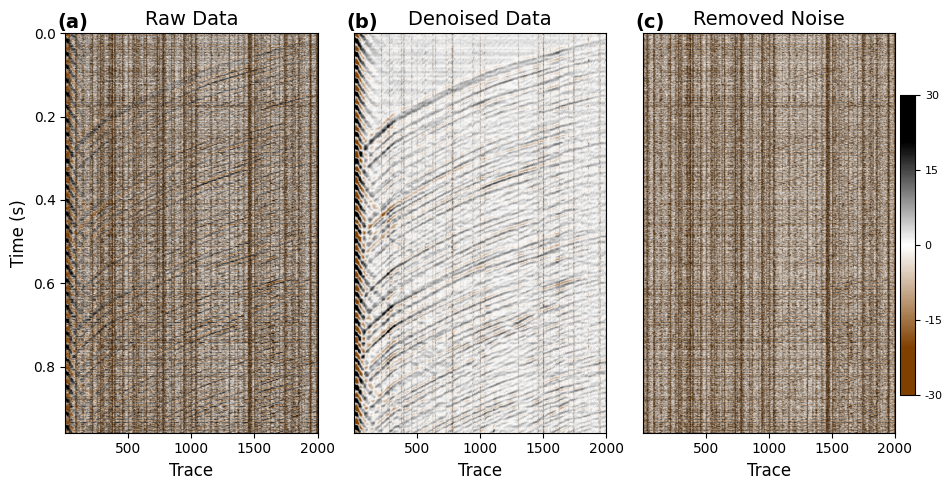

Saved figure: ./figs/FORGE/eq-36_p24_s6_drop_0.2_epoch50.png


In [5]:
# Constants
v = 30  # Color scale limit
xx, yy = 100, 0.04
v1 = 1

# Data dimensions and time axis
num_samples = data.shape[0]
num_samples_x = data.shape[1]
time_interval = 0.001
time = np.arange(0, num_samples) * time_interval

# Annotation positions
mm = -0.03
nn = 1.05

# Create the figure and subplots
fig = plt.figure(figsize=(10, 5))

# Plot 1: Raw data
ax1 = fig.add_subplot(1, 3, 1)
im1 = ax1.imshow(
    data.T, cmap=cseis(), vmin=-v, vmax=v, aspect='auto',
    extent=(1, num_samples_x, time[-1], 0)
)
ax1.set_xlabel("Trace", fontsize=12)
ax1.set_ylabel("Time (s)", fontsize=12)
ax1.set_title('Raw Data', fontsize=14)
ax1.annotate('(a)', xy=(mm, nn), xycoords='axes fraction', fontsize=14,
             fontweight='bold', va='top')

# Plot 2: Denoised data
ax2 = fig.add_subplot(1, 3, 2)
im2 = ax2.imshow(
    predicted.T, cmap=cseis(), vmin=-v, vmax=v, aspect='auto',
    extent=(1, num_samples_x, time[-1], 0)
)
ax2.set_xlabel("Trace", fontsize=12)
ax2.set_yticks([])
ax2.set_title('Denoised Data', fontsize=14)
ax2.annotate('(b)', xy=(mm, nn), xycoords='axes fraction', fontsize=14,
             fontweight='bold', va='top')

# Plot 3: Removed noise
ax3 = fig.add_subplot(1, 3, 3)
im3 = ax3.imshow(
    (data - predicted).T, cmap=cseis(), vmin=-v, vmax=v, aspect='auto',
    extent=(1, num_samples_x, time[-1], 0)
)
ax3.set_xlabel("Trace", fontsize=12)
ax3.set_yticks([])
ax3.set_title('Removed Noise', fontsize=14)
ax3.annotate('(c)', xy=(mm, nn), xycoords='axes fraction', fontsize=14,
             fontweight='bold', va='top')

# Adjust layout and add colorbar
plt.tight_layout()
fig.subplots_adjust(right=0.9)

cbar_ax = fig.add_axes([0.905, 0.2, 0.015, 0.6])
cb = plt.colorbar(im3, cax=cbar_ax)
cb.ax.tick_params(labelsize=8)
cbar_ticks = np.linspace(-v, v, 5)
cb.set_ticks(cbar_ticks)
cb.set_ticklabels([f'{tick:.0f}' for tick in cbar_ticks])

# Save and show the plot
output_file = f'{fig_path}{data_name}_epoch{epochs}.png'
plt.savefig(output_file, dpi=200, bbox_inches='tight')
plt.show()

print(f'Saved figure: {output_file}')